# Introduction

We often need to process multiple images. The question is: **What is the fastest way to do it?**

We will compare three approaches:
1.  **Sequential:** One by one (The naive loop).
2.  **Concurrent (Client-Side Batching):** Using `asyncio` to send parallel requests.
3.  **Single-Prompt (Server-Side Context Batching):** Sending *all* images in a single API call and asking for all answers at once.

We use 4 images with varying crowd densities.


In [29]:
import os
import time
import asyncio
from google import genai
from PIL import Image
import io
import matplotlib.pyplot as plt
import json

# Setup the client
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

# Using the experimental flash model for speed
MODEL_ID = "models/gemini-3-pro-preview"


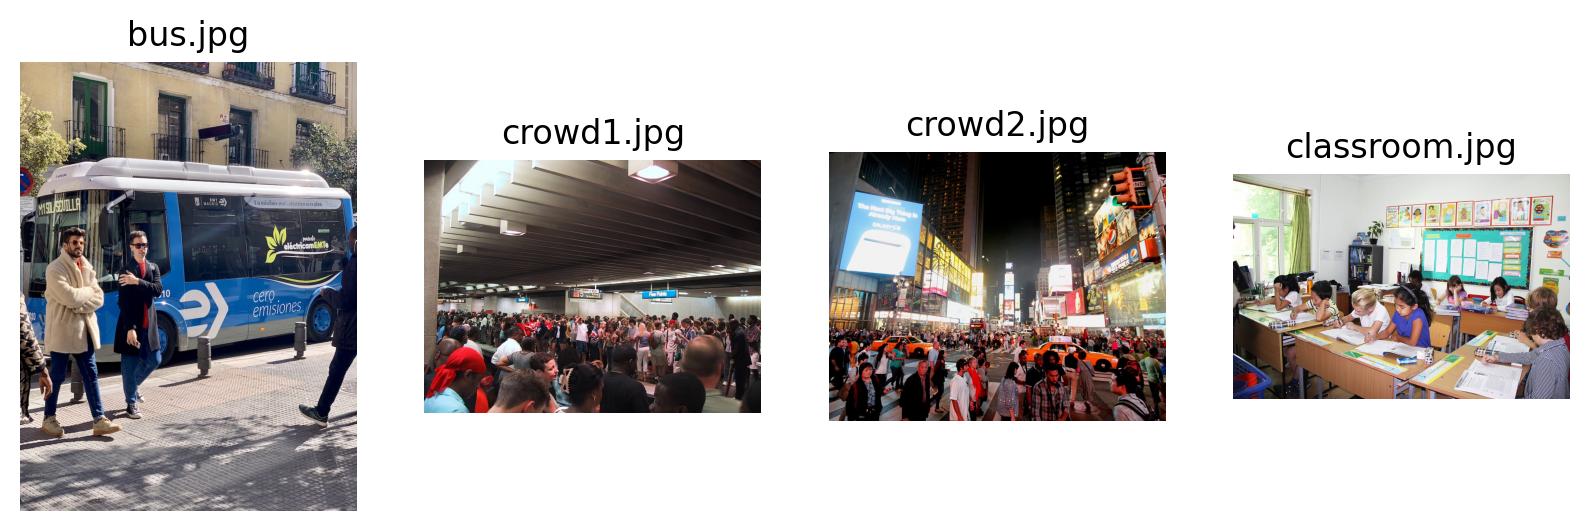

Benchmarking with 4 images.


In [30]:
image_paths = ["bus.jpg", "crowd1.jpg", "crowd2.jpg", "classroom.jpg"]
images = [Image.open(p) for p in image_paths]

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
for ax, img, name in zip(axes, images, image_paths):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis('off')
plt.show()

print(f"Benchmarking with {len(images)} images.")


## 1. Sequential Processing

The baseline: sending one request after another.


In [31]:
def run_sequential(images):
    results = []
    start_time = time.time()
    prompt = "Count the number of people in this image. Return just the integer number."
    
    for i, img in enumerate(images):
        print(f"Seq: Processing {i+1}/{len(images)}...", end="\n")
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=[img, prompt]
        )
        results.append(response.text.strip())
        
    return time.time() - start_time, results

print("Running Sequential...")
seq_time, seq_results = run_sequential(images)
print(f"Sequential Time: {seq_time:.2f}s")


Running Sequential...
Seq: Processing 1/4...
Seq: Processing 2/4...
Seq: Processing 3/4...
Seq: Processing 4/4...
Sequential Time: 85.47s


## 2. Concurrent Processing (`asyncio`)

Sending requests in parallel. This is often what we mean by "batching" in online systems—reducing latency by overlapping I/O.


In [32]:
async def process_one_async(client, img):
    prompt = "Count the number of people in this image. Return just the integer number."
    response = await client.aio.models.generate_content(
        model=MODEL_ID,
        contents=[img, prompt]
    )
    return response.text.strip()

async def run_async(images):
    start_time = time.time()
    tasks = [process_one_async(client, img) for img in images]
    results = await asyncio.gather(*tasks)
    return time.time() - start_time, results

print("Running Async...")
# await run_async(images) # Jupyter syntax
async_time, async_results = await run_async(images)
print(f"Async Time: {async_time:.2f}s")


Running Async...
Async Time: 39.35s


## 3. Single-Prompt Batching (All-in-One)

Here we ask: **"Can we pass a batch to Gemini itself?"**

Yes! We can pass multiple images in the `contents` list of a *single* request. We instruct the model to look at all of them and return a structured list of counts. 

*Note: This saves HTTP overhead but requires the model to hold all images in context.*


In [36]:
def run_single_prompt(images):
    start_time = time.time()
    
    # Construct a multimodal prompt with interleaved images
    # "Here is image 1", img1, "Here is image 2", img2...
    
    contents = []
    for i, img in enumerate(images):
        contents.append(f"Image {i+1}:")
        contents.append(img)
    
    prompt = (
        """I have provided 4 images above labeled Image 1 to Image 4.
        Count the number of people in each image respectively.

        Return the result strictly as a JSON list of integers, e.g., [10, 5, 3, 20].

        Do not include markdown formatting or backticks."""
    )
    contents.append(prompt)
    
    print("Sending Single-Prompt Request...")
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=contents
    )
    
    return time.time() - start_time, response

def parse_single_prompt_response(response, images):
    # Parse the JSON response
    try:
        text_response = response.text.strip()
        # Handle potential markdown ```json wrapping
        if text_response.startswith("```"):
            text_response = text_response.split("```", 1)[1].rsplit("```", 1)[0]
        
        results = json.loads(text_response)
        # Convert to strings to match other methods
        results = [str(x) for x in results]
    except Exception as e:
        print(f"Error parsing JSON: {e}")
        print(f"Raw response: {response.text}")
        results = ["Error"] * len(images)
        
    return results

print("Running Single-Prompt...")
single_time, response = run_single_prompt(images)


Running Single-Prompt...
Sending Single-Prompt Request...


In [39]:
print(response.text)

[4, 38, 35, 9]


In [41]:
single_results = parse_single_prompt_response(response, images)
print(f"Single-Prompt Time: {single_time:.2f}s")
print(f"Results: {single_results}")

Single-Prompt Time: 99.92s
Results: ['4', '38', '35', '9']


## Final Comparison

Which method wins?


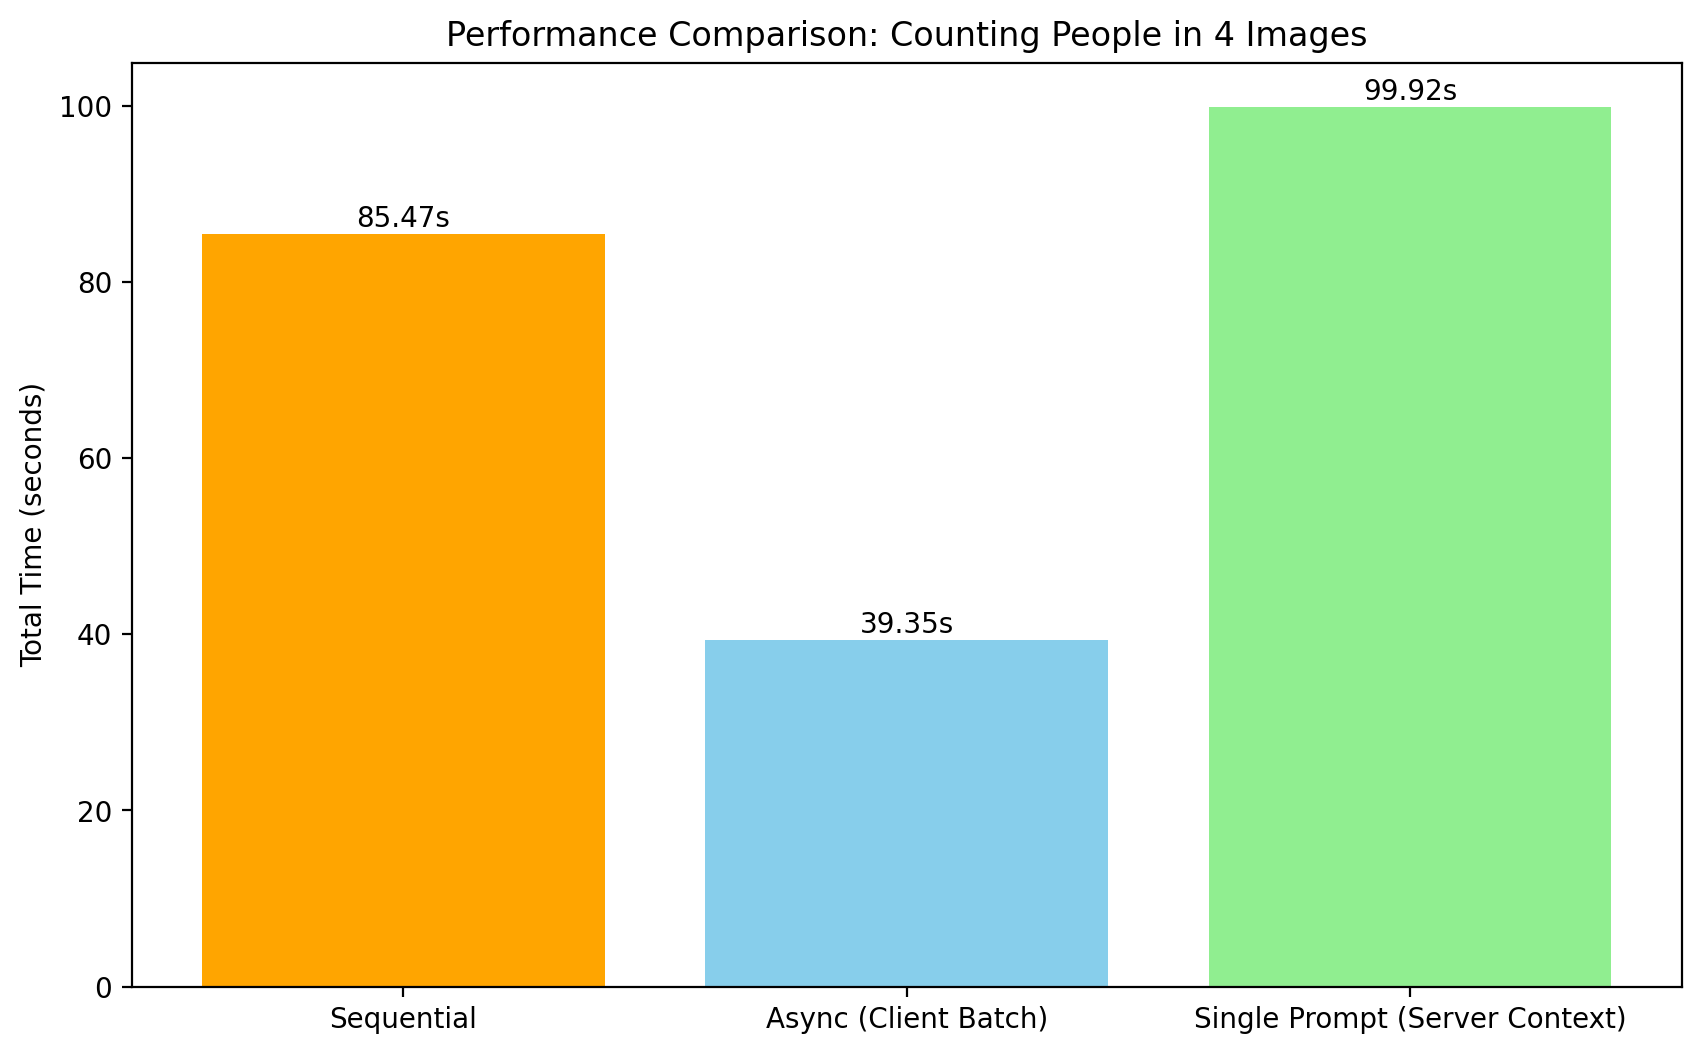

--- Consistency Check ---
Image           | Sequential | Async      | Single-Prompt
-------------------------------------------------------
bus.jpg         | 4          | 6          | 4         
crowd1.jpg      | 85         | 120        | 38        
crowd2.jpg      | 104        | 110        | 35        
classroom.jpg   | 9          | 10         | 9         


In [42]:
times = [seq_time, async_time, single_time]
labels = ['Sequential', 'Async (Client Batch)', 'Single Prompt (Server Context)']
colors = ['orange', 'skyblue', 'lightgreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, times, color=colors)
plt.ylabel('Total Time (seconds)')
plt.title('Performance Comparison: Counting People in 4 Images')

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}s', ha='center', va='bottom')

plt.show()

# Accuracy Check
print("--- Consistency Check ---")
print(f"{'Image':<15} | {'Sequential':<10} | {'Async':<10} | {'Single-Prompt':<10}")
print("-" * 55)
for i, name in enumerate(image_paths):
    print(f"{name:<15} | {seq_results[i]:<10} | {async_results[i]:<10} | {single_results[i] if i < len(single_results) else 'N/A':<10}")
